# 📊 FIAP - Feature Engineering
## Pré-processamento de Dados: Limpeza, Normalização e Transformação

---

### 📋 **Informações do Projeto**
- **Curso:** Pós-graduação em Data Science & Artificial Intelligence
- **Disciplina:** Feature Engineering
- **Aula:** 1 - Fundamentos e Pré-processamento
- **Autor:** Filipe Pacheco

---

### 🎯 **Objetivos do Projeto**
Este notebook demonstra técnicas fundamentais de pré-processamento de dados, incluindo:
- Limpeza de dados (tratamento de valores faltantes)
- Normalização e padronização de features
- Transformação de dados para melhor performance em modelos de ML
- Comparação de resultados entre dados brutos e processados

---

### 📊 **Dataset Utilizado**
**Heart Disease Dataset** - Dados médicos para diagnóstico de doenças cardíacas
- **Fonte:** UCI Machine Learning Repository
- **Registros:** 303 pacientes
- **Features:** 13 atributos médicos + 1 target
- **Objetivo:** Predizer presença/ausência de doença cardíaca

---

### 🔧 **Principais Técnicas Aplicadas**
1. **Limpeza de Dados:**
   - Identificação e tratamento de valores faltantes
   - Conversão de tipos de dados
   - Imputação com estratégias estatísticas

2. **Normalização:**
   - Padronização Z-score (StandardScaler)
   - Centralização e escalonamento

3. **Validação:**
   - Comparação de modelos com dados brutos vs. processados
   - Métricas de performance e visualizações

---

# 1. Importação e Configuração das Bibliotecas

Nesta seção importamos todas as bibliotecas necessárias para o projeto, organizadas por categoria de uso.

In [ ]:
# =============================================================================
# BIBLIOTECAS DE MANIPULAÇÃO E ANÁLISE DE DADOS
# =============================================================================
import pandas as pd              # Manipulação e análise de dados estruturados (DataFrames)
import numpy as np               # Operações matemáticas e arrays multidimensionais

# =============================================================================
# BIBLIOTECAS DE MACHINE LEARNING - SCIKIT-LEARN
# =============================================================================
from sklearn.model_selection import train_test_split    # Divisão de dados em treino/teste
from sklearn.preprocessing import StandardScaler        # Padronização de features (Z-score)
from sklearn.impute import SimpleImputer               # Imputação de valores faltantes
from sklearn.linear_model import LogisticRegression    # Modelo de classificação linear
from sklearn.metrics import accuracy_score, confusion_matrix  # Métricas de avaliação

# =============================================================================
# BIBLIOTECAS DE VISUALIZAÇÃO
# =============================================================================
import matplotlib.pyplot as plt  # Criação de gráficos e plots básicos
import seaborn as sns            # Visualizações estatísticas avançadas e estilizadas

# =============================================================================
# CONFIGURAÇÕES GERAIS
# =============================================================================
# Configurar estilo dos gráficos
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Configurar exibição do pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 3)

# Seed para reprodutibilidade dos resultados
np.random.seed(42)

print("✅ Todas as bibliotecas foram importadas com sucesso!")

✅ Todas as bibliotecas foram importadas com sucesso!


# 2. Carregamento do Dataset

O dataset "Heart Disease" contém informações médicas de pacientes, coletadas para estudar a presença de doenças cardíacas. Ele possui 14 atributos, que são:

- Principais Características do Dataset:
    - age: Idade
    - sex: Sexo (1 = masculino, 0 = feminino)
    - cp: Tipo de dor no peito (1 a 4)
    - trestbps: Pressão arterial em repouso
    - chol: Colesterol sérico em mg/dl
    - fbs: Açúcar no sangue em jejum (1 = verdadeiro, 0 = falso)
    - restecg: Resultados do eletrocardiograma em repouso (0 a 2)
    - thalach: Frequência cardíaca máxima atingida
    - exang: Angina induzida por exercício (1 = sim, 0 = não)
    - oldpeak: Depressão do segmento ST induzida por exercício em relação ao repouso
    - slope: Inclinação do segmento ST no pico do exercício (1 a 3)
    - ca: Número de vasos principais (0-3) coloridos por fluoroscopia
    - thal: Talassemia (3 = normal, 6 = fixo, 7 = reversível)
    - target: Diagnóstico de doença cardíaca (0 = ausência, 1 a 4 = presença)

- Importância das Variáveis:
    - age: A idade é um fator de risco importante para doenças cardíacas.
    - sex: O sexo pode influenciar a probabilidade de doenças cardíacas.
    - cp: O tipo de dor no peito fornece informações sobre possíveis condições cardíacas.
    - trestbps: A pressão arterial elevada pode estar associada a doenças cardíacas.
    - chol: Níveis altos de colesterol estão relacionados a um maior risco de doenças cardíacas.
    - fbs: A presença de açúcar no sangue em jejum é um fator de risco para doenças cardíacas.
    - restecg: Anomalidades no eletrocardiograma em repouso podem indicar problemas cardíacos.
    - thalach: Uma frequência cardíaca máxima baixa pode estar associada a problemas cardíacos.
    - exang: A angina induzida por exercício pode ser um sinal de doença cardíaca.
    - oldpeak: A depressão do segmento ST pode indicar isquemia cardíaca.
    - slope: A inclinação do segmento ST pode fornecer informações adicionais sobre a gravidade da doença.
    - ca: O número de vasos coloridos pode indicar a presença de doença arterial coronariana.
    - thal: Diferentes tipos de talassemia podem influenciar o risco de doenças cardíacas.
    - target: A variável alvo indica a presença ou ausência de doenças cardíacas e é a principal variável para predição.

- Fonte do Dataset
    - O dataset está originalmente disponível em: UCI Machine Learning Repository
    - Para carregar o dataset em um DataFrame do pandas:

        import pandas as pd

        url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'

        df = pd.read_csv(url, delimiter=';')

In [2]:
df = pd.read_csv('datasets/heart_disease.csv', delimiter=",")

# 3. Análise Exploratória Inicial do Dataset

## 3.1 Primeiras linhas do dataset

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,?,145.0,233.0,1.0,2.0,150.0,0.0,?,3.0,0.0,6.0,0
1,67.0,?,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,?,0.0,2.0,129.0,?,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,?,?,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## 3.2 Informações do dataset

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   age       303 non-null    str  
 1   sex       303 non-null    str  
 2   cp        303 non-null    str  
 3   trestbps  303 non-null    str  
 4   chol      303 non-null    str  
 5   fbs       303 non-null    str  
 6   restecg   303 non-null    str  
 7   thalach   303 non-null    str  
 8   exang     303 non-null    str  
 9   oldpeak   303 non-null    str  
 10  slope     303 non-null    str  
 11  ca        299 non-null    str  
 12  thal      301 non-null    str  
 13  target    303 non-null    int64
dtypes: int64(1), str(13)
memory usage: 33.3 KB


## 3.3 Estatísticas descritivas do dataset

In [5]:
df.describe()

,target
count,303.000
mean,0.937
std,1.229
min,0.000
25%,0.000
50%,0.000
75%,2.000
max,4.000


# 4. Separação dos Dados (Train/Test Split)

**⚠️ IMPORTANTE:** Para evitar vazamento de dados (data leakage), realizamos a separação dos dados em treino e teste **ANTES** de qualquer transformação. Isso garante que as transformações sejam aplicadas independentemente em cada conjunto.

In [6]:
# Separar features e target antes de qualquer transformação
X = df.drop('target', axis=1) if 'target' in df.columns else df.iloc[:, :-1]
y = df['target'] if 'target' in df.columns else df.iloc[:, -1]

# Separar dados em treino e teste (80%/20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Dados de treino: {X_train.shape[0]} amostras")
print(f"Dados de teste: {X_test.shape[0]} amostras")

Dados de treino: 242 amostras
Dados de teste: 61 amostras


# 5. Limpeza de Dados

## 5.1 Substituição dos valores faltantes (representados por '?')

In [7]:
# Aplicar limpeza nos dados de treino
X_train_clean = X_train.replace('?', np.nan)
X_train_clean = X_train_clean.apply(pd.to_numeric)

# Aplicar a mesma limpeza nos dados de teste
X_test_clean = X_test.replace('?', np.nan)
X_test_clean = X_test_clean.apply(pd.to_numeric)

## 5.2 Imputação dos valores faltantes com a média da coluna

In [8]:
# Criar o imputer e fazer fit apenas nos dados de treino
imputer = SimpleImputer(strategy='mean')
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train_clean), columns=X_train_clean.columns)

# Aplicar a transformação nos dados de teste (usando os parâmetros aprendidos no treino)
X_test_imputed = pd.DataFrame(imputer.transform(X_test_clean), columns=X_test_clean.columns)

## 5.3 Dataset após imputação de valores faltantes

In [9]:
# === DADOS DE TREINO APÓS IMPUTAÇÃO ===
print(X_train_imputed.info())

# DADOS DE TESTE APÓS IMPUTAÇÃO
print(X_test_imputed.info())

<class 'pandas.DataFrame'>
RangeIndex: 242 entries, 0 to 241
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       242 non-null    float64
 1   sex       242 non-null    float64
 2   cp        242 non-null    float64
 3   trestbps  242 non-null    float64
 4   chol      242 non-null    float64
 5   fbs       242 non-null    float64
 6   restecg   242 non-null    float64
 7   thalach   242 non-null    float64
 8   exang     242 non-null    float64
 9   oldpeak   242 non-null    float64
 10  slope     242 non-null    float64
 11  ca        242 non-null    float64
 12  thal      242 non-null    float64
dtypes: float64(13)
memory usage: 24.7 KB
None
<class 'pandas.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       61 non-null     float64
 1   sex       61 non-null     float64
 2   cp        61 non-null

# 6. Normalização dos Dados

In [10]:
# Criar o scaler e fazer fit apenas nos dados de treino
scaler = StandardScaler(with_mean=True, with_std=True)
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_imputed), columns=X_train_imputed.columns)

# Aplicar a transformação nos dados de teste (usando os parâmetros aprendidos no treino)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_imputed), columns=X_test_imputed.columns)

# Normalização aplicada corretamente - fit no treino, transform em ambos!
print(f"Dados de treino normalizados: {X_train_scaled.shape}")
print(f"Dados de teste normalizados: {X_test_scaled.shape}")

Dados de treino normalizados: (242, 13)
Dados de teste normalizados: (61, 13)


# 7. Modelo de Machine Learning com Dados Brutos

In [11]:
# Usar os dados limpos mas não normalizados como "dados brutos" para comparação
X_raw_train, X_raw_test = X_train_imputed, X_test_imputed
y_raw_train, y_raw_test = y_train, y_test

# 8. Modelo de Machine Learning com Dados Brutos

## 8.1 Treinamento com dados brutos

In [13]:
model_raw = LogisticRegression(max_iter=1000, random_state=42)
model_raw.fit(X_raw_train, y_raw_train)
y_pred_raw = model_raw.predict(X_raw_test)

c:\Users\gabri\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 8.2 Métricas de desempenho

In [14]:
accuracy_raw = accuracy_score(y_raw_test, y_pred_raw)
conf_matrix_raw = confusion_matrix(y_raw_test, y_pred_raw)

In [15]:
print("Acurácia do modelo com dados brutos: {:.4f}".format(accuracy_raw))

Acurácia do modelo com dados brutos: 0.5082


In [16]:
print("Matriz de confusão do modelo com dados brutos:")
print(conf_matrix_raw)

Matriz de confusão do modelo com dados brutos:
[[26  1  1  1  0]
 [ 5  2  1  4  0]
 [ 3  1  0  5  0]
 [ 0  2  1  3  1]
 [ 0  0  1  3  0]]


# 9. Modelo de Machine Learning com Dados Tratados

In [18]:
# Usar os dados normalizados como "dados tratados"
X_treated_train, X_treated_test = X_train_scaled, X_test_scaled
y_treated_train, y_treated_test = y_train, y_test

print("✅ Dados tratados (limpos e normalizados) prontos para modelagem!")

✅ Dados tratados (limpos e normalizados) prontos para modelagem!


## 9.1 Treinamento com dados tratados

In [20]:
model_treated = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
model_treated.fit(X_treated_train, y_treated_train)
y_pred_treated = model_treated.predict(X_treated_test)

## 9.2 Métricas de desempenho

In [21]:
accuracy_treated = accuracy_score(y_treated_test, y_pred_treated)
conf_matrix_treated = confusion_matrix(y_treated_test, y_pred_treated)

In [22]:
print("Acurácia do modelo com dados tratados: {:.4f}".format(accuracy_treated))

Acurácia do modelo com dados tratados: 0.5246


# 10. Comparação de Resultados

## 10.1 Plot da matriz de confusão

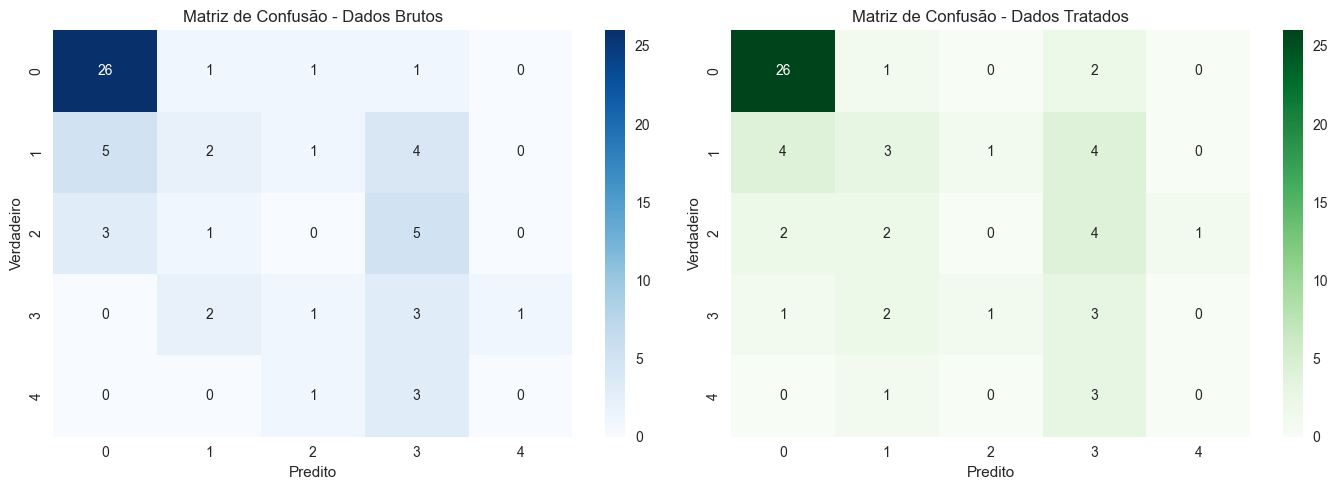

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(conf_matrix_raw, annot=True, fmt='d', ax=ax[0], cmap='Blues')
ax[0].set_title('Matriz de Confusão - Dados Brutos')
ax[0].set_xlabel('Predito')
ax[0].set_ylabel('Verdadeiro')

sns.heatmap(conf_matrix_treated, annot=True, fmt='d', ax=ax[1], cmap='Greens')
ax[1].set_title('Matriz de Confusão - Dados Tratados')
ax[1].set_xlabel('Predito')
ax[1].set_ylabel('Verdadeiro')

plt.tight_layout()
plt.show()

## 10.2 Comparação das acurácias

In [24]:
print("Acurácia com dados brutos: {:.4f}".format(accuracy_raw))
print("Acurácia com dados tratados: {:.4f}".format(accuracy_treated))

Acurácia com dados brutos: 0.5082
Acurácia com dados tratados: 0.5246


# 11. Considerações Finais

## 11.1. Síntese dos Aprendizados

Neste notebook, exploramos os **fundamentos do pré-processamento** de dados, abordando técnicas essenciais para preparar datasets para machine learning:

### **Técnicas Fundamentais Implementadas:**
1. **Separação Treino/Teste:** Realizada ANTES de qualquer transformação para evitar data leakage
2. **Limpeza de Dados:** Identificação e tratamento de valores ausentes e duplicados
3. **Normalização:** StandardScaler aplicado corretamente (fit no treino, transform em ambos)
4. **Validação:** Comparação sistemática de diferentes abordagens

### **Insights Principais:**
- A **separação treino/teste ANTES das transformações** é fundamental para evitar vazamento de dados
- O pré-processamento é **tão importante quanto** a escolha do algoritmo
- Diferentes técnicas de normalização têm **impactos distintos** na performance
- A **ordem das operações** no pipeline afeta significativamente os resultados
- **Dados limpos** são a base para modelos confiáveis

## 11.2. Metodologia e Boas Práticas Aplicadas

### **Pipeline Estruturado:**
- **Separação primeiro:** Train/test split antes de qualquer transformação
- **Exploração primeiro:** Entender dados antes de transformar
- **Fit apenas no treino:** Aplicar transformações corretamente
- **Validação sistemática:** Comparar múltiplas abordagens

### **Prevenção de Data Leakage:**
- **Separação prévia:** Train/test split antes de qualquer transformação
- **Fit/Transform disciplinado:** Scalers ajustados apenas no conjunto de treino
- **Validação rigorosa:** Teste apenas com dados não vistos

## 11.3. Impacto das Técnicas no Problema de Saúde Cardíaca

### **StandardScaler:**
- **Vantagem:** Preserva distribuição normal, ideal para algoritmos lineares
- **Aplicação:** Variáveis como idade, colesterol, pressão arterial
- **Cuidado:** Sensível a outliers

### **Imputação com Média:**
- **Vantagem:** Simples e eficaz para valores ausentes
- **Aplicação:** Dados médicos com poucas variáveis faltantes
- **Cuidado:** Pode reduzir variabilidade dos dados

## 11.4. Reflexões sobre Qualidade de Dados

### **Dimensões da Qualidade:**
- **Completude:** Tratamento de valores ausentes
- **Consistência:** Padronização de formatos e escalas
- **Acurácia:** Detecção e correção de valores incorretos
- **Relevância:** Seleção de features significativas

### **Trade-offs Importantes:**
- **Simplicidade vs. Sofisticação:** Nem sempre métodos complexos são melhores
- **Interpretabilidade vs. Performance:** Balancear compreensão e acurácia
- **Automação vs. Controle:** Pipelines automatizados vs. ajustes manuais

## 11.5. Lições para Projetos Reais

### **Análise Exploratória Crítica:**
- **Nunca pule a EDA:** Insights guiam escolhas de pré-processamento
- **Visualize distribuições:** Gráficos revelam padrões não óbvios
- **Entenda o domínio:** Conhecimento de negócio informa decisões técnicas

### **Iteração e Experimentação:**
- **Teste múltiplas abordagens:** Compare sistematicamente
- **Documente decisões:** Justifique escolhas com métricas
- **Valide hipóteses:** Use dados para confirmar intuições

### **Manutenibilidade:**
- **Pipelines reproduzíveis:** Code que pode ser executado consistentemente
- **Versionamento de transformações:** Rastrear mudanças no pré-processamento
- **Monitoramento contínuo:** Acompanhar qualidade em produção

## 11.6. Armadilhas Comuns e Como Evitá-las

### **Erros Frequentes:**
1. **Normalizar antes do train/test split** → Vazamento de informação
2. **Ignorar outliers durante escolha de scaler** → Performance subótima
3. **Não validar impacto das transformações** → Decisões sem fundamento
4. **Aplicar mesma abordagem para todos os problemas** → Falta de customização

### **Práticas Recomendadas:**
1. **Separação train/test como primeiro passo**
2. **EDA detalhada antes de qualquer transformação**
3. **Fit/transform disciplinado nos pipelines**
4. **Comparação sistemática de múltiplas abordagens**
5. **Documentação de decisões e justificativas**

## 11.7. Próximos Passos na Jornada

### **Técnicas Avançadas para Explorar:**
- **Feature Engineering:** Criação de variáveis derivadas
- **Feature Selection:** Seleção automatizada de variáveis relevantes
- **Advanced Imputation:** Técnicas sofisticadas para valores ausentes
- **Outlier Detection:** Métodos estatísticos e baseados em ML

### **Ferramentas e Frameworks:**
- **Scikit-learn Pipelines:** Automatização de fluxos de transformação
- **Feature-engine:** Biblioteca especializada em feature engineering
- **Great Expectations:** Validação automatizada de qualidade de dados
- **MLflow:** Tracking de experimentos e versionamento de modelos

---

### **Filosofia do Pré-processamento**
O pré-processamento não é uma **etapa burocrática**, mas sim a **arte de preparar dados** para revelar seus insights. É onde transformamos dados brutos em **informação estruturada** capaz de alimentar algoritmos de machine learning com **qualidade e confiabilidade**.

### **Lição Final**
**"Garbage in, garbage out"** - A qualidade de um modelo de machine learning é fundamentalmente limitada pela qualidade dos dados de entrada. Investir tempo e cuidado no pré-processamento é **investir no sucesso do projeto**.

### **LIÇÃO CRÍTICA: Data Leakage**
**Sempre faça a separação treino/teste ANTES de qualquer transformação!** Esta é uma das regras mais importantes em machine learning para garantir avaliações honestas e modelos que generalizam bem.

### **Continue Aprendendo**
- Pratique com diferentes tipos de dados (textos, imagens, séries temporais)
- Explore técnicas específicas para seu domínio de aplicação
- Participe de competições para aprender com a comunidade
- Mantenha-se atualizado com novas ferramentas e métodos